# Metadata Analytics Major Porject: Preliminary Analysis 


In [85]:
import json 

file_name = "PublicAssistanceFundedProjectsDetails.json"
with open(file_name, "r" ) as fh:
    data = json.load(fh)

In [86]:
len(data["PublicAssistanceFundedProjectsDetails"])

720791

In [87]:
data

{'PublicAssistanceFundedProjectsDetails': [{'disasterNumber': 1603,
   'declarationDate': '2005-08-29T00:00:00.000Z',
   'incidentType': 'Hurricane',
   'pwNumber': 968,
   'applicationTitle': '(PW# 968) PUBLIC BUILDINGS AND FACILITIES',
   'applicantId': '071-55000-00',
   'damageCategoryCode': 'E',
   'damageCategoryDescrip': 'Buildings and Equipment',
   'projectStatus': 'Active',
   'projectProcessStep': 'Pending Closeout Peer Review',
   'projectSize': 'Large',
   'county': 'Orleans Parish',
   'countyCode': '71',
   'stateAbbreviation': 'LA',
   'stateNumberCode': '22',
   'projectAmount': 233669.57,
   'federalShareObligated': 233669.57,
   'totalObligated': 234361.28,
   'lastObligationDate': '2025-08-09T16:15:12.000Z',
   'firstObligationDate': '2005-12-05T23:48:04.000Z',
   'mitigationAmount': 0,
   'gmProjectId': 903775,
   'gmApplicantId': 248464,
   'lastRefresh': '2025-09-26T15:04:12.883Z',
   'hash': '3181e8d84d820bf694e79c427a4d505bfa96950a'},
  {'disasterNumber': 1603,

## Pre-processing : 

In [89]:
import pandas as pd

df = pd.DataFrame(data["PublicAssistanceFundedProjectsDetails"])
print(df.shape)   # rows, columns / dimensions 
df.head() # printing the sample values 


(720791, 25)


,disasterNumber,declarationDate,incidentType,pwNumber,applicationTitle,applicantId,damageCategoryCode,damageCategoryDescrip,projectStatus,projectProcessStep,...,projectAmount,federalShareObligated,totalObligated,lastObligationDate,firstObligationDate,mitigationAmount,gmProjectId,gmApplicantId,lastRefresh,hash
0,1603,2005-08-29T00:00:00.000Z,Hurricane,968,(PW# 968) PUBLIC BUILDINGS AND FACILITIES,071-55000-00,E,Buildings and Equipment,Active,Pending Closeout Peer Review,...,233669.57,233669.57,234361.28,2025-08-09T16:15:12.000Z,2005-12-05T23:48:04.000Z,0.0,903775,248464,2025-09-26T15:04:12.883Z,3181e8d84d820bf694e79c427a4d505bfa96950a
1,1603,2005-08-29T00:00:00.000Z,Hurricane,11100,(PW# 11100) EJE0210 BUILDING #1 CLASSROOMS AND...,051-UI84J-00,E,Buildings and Equipment,Active,Pending Closeout Completion,...,4019385.22,4019385.22,4084385.55,2014-10-23T19:19:16.000Z,2006-08-04T17:13:39.000Z,0.0,910257,248665,2025-09-26T15:04:12.883Z,75cb27a08b14e99e6cecc2ab969e929d98ca90b5
2,1603,2005-08-29T00:00:00.000Z,Hurricane,17454,(PW# 17454) Record Stabilization,051-U415A-00,E,Buildings and Equipment,Active,Pending Applicant Project Review,...,779919.42,779919.42,779919.41,2023-06-22T23:28:34.000Z,2008-07-11T21:50:14.000Z,0.0,909572,248644,2025-09-26T15:04:12.883Z,bd92e79e80e451991e7d3dba32247d6aea806963
3,1603,2005-08-29T00:00:00.000Z,Hurricane,20494,(PW# 20494) CONSOLIDATED ALTERNATE PROJECT,071-55000-00,E,Buildings and Equipment,Active,Pending PDMG Project Review,...,45935305.48,45935305.48,46387164.28,2023-01-11T21:55:53.000Z,2012-12-17T22:24:26.000Z,0.0,903271,248464,2025-09-26T15:04:12.883Z,ed348ea796bcf01eb9a081e3bcc27e0195e5b3bf
4,1603,2005-08-29T00:00:00.000Z,Hurricane,21029,(PW# 21029) TWENTY ARPENT CANAL ROAD CROSSINGS...,087-99087-00,C,Roads and Bridges,Active,Pending Project Closeout Final Review,...,934294.93,934294.93,943661.23,2016-07-21T21:05:29.000Z,2016-07-21T21:05:29.000Z,0.0,905745,248478,2025-09-26T15:04:12.883Z,ddb1bc8bb680755395378646518fca7d2bc2d4f1


In [90]:
# Count missing values per column
missing_summary = df.isnull().sum().sort_values(ascending=False)
print(missing_summary.head(20))

# % of missing values
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct)


county                   12357
applicantId                  9
disasterNumber               0
stateNumberCode              0
lastRefresh                  0
gmApplicantId                0
gmProjectId                  0
mitigationAmount             0
firstObligationDate          0
lastObligationDate           0
totalObligated               0
federalShareObligated        0
projectAmount                0
countyCode                   0
stateAbbreviation            0
declarationDate              0
projectSize                  0
projectProcessStep           0
projectStatus                0
damageCategoryDescrip        0
dtype: int64
disasterNumber           0.000000
declarationDate          0.000000
incidentType             0.000000
pwNumber                 0.000000
applicationTitle         0.000000
applicantId              0.001249
damageCategoryCode       0.000000
damageCategoryDescrip    0.000000
projectStatus            0.000000
projectProcessStep       0.000000
projectSize              0.

In [91]:
duplicates_in_data = df.duplicated().sum()
print(f"Duplicate rows: {duplicates_in_data}")

Duplicate rows: 0


## Review : 

The entire dataset is almost clean, excpet for missing 1.71% county and 0.001% of applicantId . We can consider to remove the missing data. This means, on an overall - the data quality is excellent!

In [93]:
df = df.dropna(subset=["applicantId"])
df = df.dropna(subset=["county"])

In [94]:
df.shape # to check the dataframe - to ensure we have a lot of records. None of the columns are removed. 

(708425, 25)

## Stat Analysis

In [96]:
print("Average obligated funding:", df["totalObligated"].mean())
print("Median obligated funding:", df["totalObligated"].median())
print("Max obligated funding:", df["totalObligated"].max())
print("Total funding in dataset:", df["totalObligated"].sum())


Average obligated funding: 363186.0636301654
Median obligated funding: 10821.79
Max obligated funding: 8152479683.8
Total funding in dataset: 257290087127.19995


In [97]:
print(df["projectSize"].value_counts(normalize=True) * 100)  # % distribution


projectSize
Small    85.291598
Large    14.708402
Name: proportion, dtype: float64


In [98]:
top_disasters = (
    df.groupby("incidentType")["totalObligated"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)
print(top_disasters)


incidentType
Hurricane          1.230702e+11
Biological         9.116787e+10
Severe Storm(s)    1.549361e+10
Flood              6.102552e+09
Wildfire           5.814630e+09
Name: totalObligated, dtype: float64


In [99]:
top_states = (
    df.groupby("stateAbbreviation")["totalObligated"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)
print(top_states)


stateAbbreviation
PR    3.924165e+10
NY    3.188427e+10
LA    2.553407e+10
CA    2.322901e+10
VI    2.268374e+10
Name: totalObligated, dtype: float64


In [100]:
!pip install seaborn

/var/folders/tl/2xf3fchx0jj0f4k4cld6c4j40000gn/T/ipykernel_3602/2338667491.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="projectSize", data=df, palette="Set2")


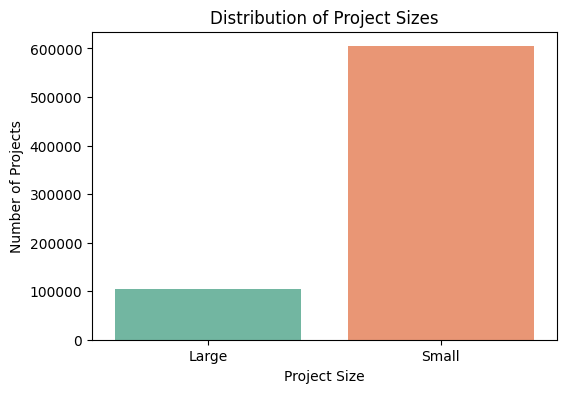

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="projectSize", data=df, palette="Set2")
plt.title("Distribution of Project Sizes")
plt.xlabel("Project Size")
plt.ylabel("Number of Projects")
plt.show()


/var/folders/tl/2xf3fchx0jj0f4k4cld6c4j40000gn/T/ipykernel_3602/4178176662.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="projectSize", y="totalObligated", data=funding_by_size, palette="Set1")


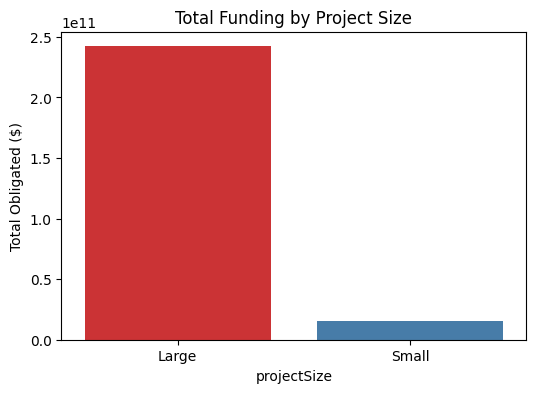

In [102]:
funding_by_size = df.groupby("projectSize")["totalObligated"].sum().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x="projectSize", y="totalObligated", data=funding_by_size, palette="Set1")
plt.title("Total Funding by Project Size")
plt.ylabel("Total Obligated ($)")
plt.show()


/var/folders/tl/2xf3fchx0jj0f4k4cld6c4j40000gn/T/ipykernel_3602/1671518922.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_incidents.values, y=top_incidents.index, palette="viridis")


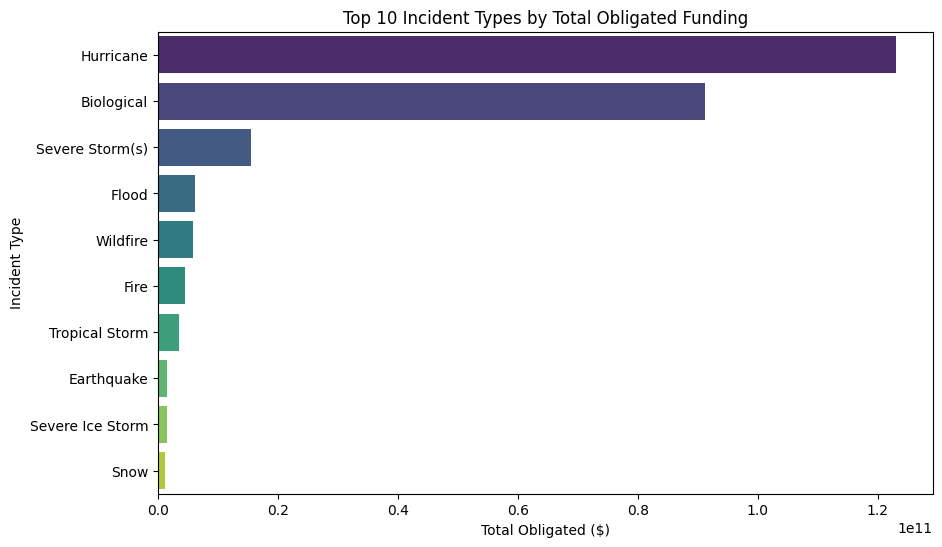

In [103]:
top_incidents = (
    df.groupby("incidentType")["totalObligated"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=top_incidents.values, y=top_incidents.index, palette="viridis")
plt.title("Top 10 Incident Types by Total Obligated Funding")
plt.xlabel("Total Obligated ($)")
plt.ylabel("Incident Type")
plt.show()


/var/folders/tl/2xf3fchx0jj0f4k4cld6c4j40000gn/T/ipykernel_3602/184601710.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.values, y=top_states.index, palette="cubehelix")


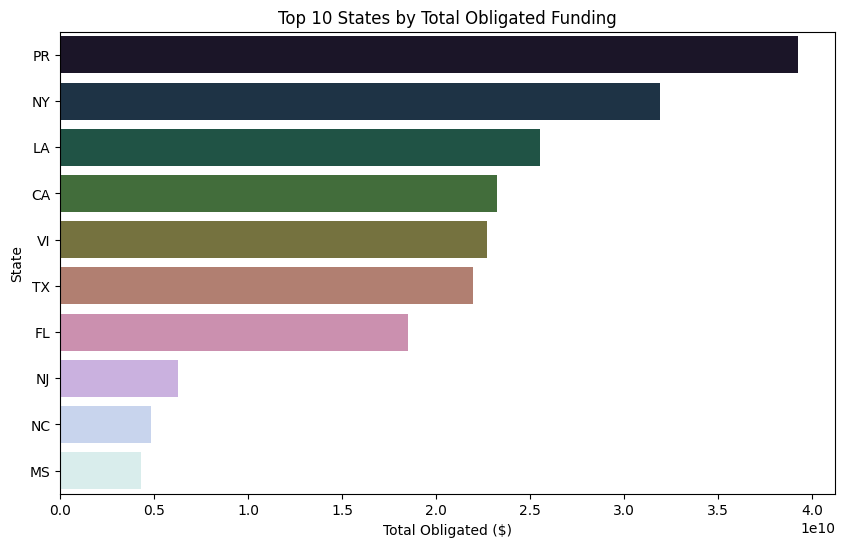

In [104]:
top_states = (
    df.groupby("stateAbbreviation")["totalObligated"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=top_states.values, y=top_states.index, palette="cubehelix")
plt.title("Top 10 States by Total Obligated Funding")
plt.xlabel("Total Obligated ($)")
plt.ylabel("State")
plt.show()


In [124]:
# RQ1 - quick prelim analysis : 
# Grouping by date and disaster type 
# computing per project funding and per disaster funding: 

funding_state = df.groupby("stateAbbreviation")["totalObligated"].sum().sort_values(ascending=False)
funding_disaster = df.groupby("incidentType")["totalObligated"].sum().sort_values(ascending=False)

In [126]:
funding_state

stateAbbreviation
PR     3.924165e+10
NY     3.188427e+10
LA     2.553407e+10
CA     2.322901e+10
VI     2.268374e+10
           ...     
ACT    8.173140e+05
HT     5.131825e+05
CTL    3.594175e+05
MCN    3.354858e+05
TCN    6.299600e+04
Name: totalObligated, Length: 64, dtype: float64

In [128]:
funding_disaster

incidentType
Hurricane                                                      1.230702e+11
Biological                                                     9.116787e+10
Severe Storm(s)                                                1.549361e+10
Flood                                                          6.102552e+09
Wildfire                                                       5.814630e+09
Fire                                                           4.487589e+09
Tropical Storm                                                 3.555996e+09
Earthquake                                                     1.538719e+09
Severe Ice Storm                                               1.513018e+09
Snow                                                           1.122811e+09
Winter Storm                                                   9.323829e+08
Other                                                          7.808034e+08
Tornado                                                        5.367337e+08

In [130]:
# RQ2 : Are the smaller projects processed more quickly?

In [140]:
type(df["firstObligationDate"])

pandas.core.series.Series

In [142]:
df["firstObligationDate"] = pd.to_datetime(df["firstObligationDate"], errors="coerce")
df["lastObligationDate"] = pd.to_datetime(df["lastObligationDate"], errors="coerce")
df["declarationDate"] = pd.to_datetime(df["declarationDate"], errors="coerce")
print(df["firstObligationDate"].dtype)


df["lag_days"] = (df["firstObligationDate"] - df["declarationDate"]).dt.days
df.groupby("projectSize")["lag_days"].describe()


datetime64[ns, UTC]


,count,mean,std,min,25%,50%,75%,max
projectSize,,,,,,,,
Large,104198.0,469.020672,545.214568,2.0,128.0,262.0,595.0,6535.0
Small,604227.0,255.443198,320.945462,6.0,88.0,153.0,275.0,6871.0


In [145]:
# RQ 3 : Can metadata predict funding size category?

In [147]:
def categorize_funding(x):
    if x < 1e5: return "Small"
    elif x < 1e6: return "Medium"
    else: return "Large"
df["fundingCategory"] = df["totalObligated"].apply(categorize_funding)


In [151]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 6.5 MB/s eta 0:00:00 MB/s eta 0:00:01:01


In [157]:
!pip install --upgrade nbformat


  Using cached jsonschema-4.25.1-py3-none-any.whl.metadata (7.6 kB)
  Using cached referencing-0.36.2-py3-none-any.whl.metadata (2.8 kB)
Using cached jsonschema-4.25.1-py3-none-any.whl (90 kB)
Using cached referencing-0.36.2-py3-none-any.whl (26 kB)


In [163]:
!pip install --upgrade nbformat


In [167]:
import plotly.express as px

# Aggregate total funding by state
state_funding = df.groupby("stateAbbreviation")["totalObligated"].sum().reset_index()

# Plot choropleth
fig = px.choropleth(
    state_funding,
    locations="stateAbbreviation",   # state codes
    locationmode="USA-states",
    color="totalObligated",
    color_continuous_scale="Viridis",
    scope="usa",
    title="Total FEMA Public Assistance Obligated Funding by State"
)
fig.write_html("fema_state_funding.html")



In [177]:
# The above fundings are skewed (hence using logs) 

import numpy as np
import plotly.express as px

# Aggregate total funding by state
state_funding = df.groupby("stateAbbreviation")["totalObligated"].sum().reset_index()

# Add a log-transformed column (avoid log(0) with +1)
state_funding["logFunding"] = np.log10(state_funding["totalObligated"] + 1)

# Plot choropleth with log scale
fig = px.choropleth(
    state_funding,
    locations="stateAbbreviation",   # state codes
    locationmode="USA-states",
    color="logFunding",
    color_continuous_scale="Viridis",
    scope="usa",
    title="Total FEMA Obligated Funding by State (log10 scale)"
)

# Save as interactive HTML
fig.write_html("fema_state_funding_log.html")


In [171]:
state_avg = df.groupby("stateAbbreviation")["totalObligated"].mean().reset_index()

fig = px.choropleth(
    state_avg,
    locations="stateAbbreviation",
    locationmode="USA-states",
    color="totalObligated",
    color_continuous_scale="Plasma",
    scope="usa",
    title="Average FEMA Project Funding by State"
)
fig.write_html("Total_fema_state_funding.html")


In [179]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# --- 0) PREP: make sure dates/numbers are ready (skip if you already did this)
df["declarationDate"]   = pd.to_datetime(df["declarationDate"], errors="coerce")
df["firstObligationDate"] = pd.to_datetime(df["firstObligationDate"], errors="coerce")
df["lastObligationDate"]  = pd.to_datetime(df["lastObligationDate"], errors="coerce")

# --- 1) Clean minimal fields used here
tmp = df.copy()
tmp["incidentType"] = tmp["incidentType"].fillna("Unknown")
tmp["stateAbbreviation"] = tmp["stateAbbreviation"].str.upper()

# Plotly "USA-states" works best with two-letter state/territory codes.
# filter strictly to 2-letter codes (not include missing regions):
tmp = tmp[tmp["stateAbbreviation"].str.len() == 2]

# --- 2) Aggregate: total funding per state per incident type
g = (tmp.groupby(["incidentType", "stateAbbreviation"])["totalObligated"]
        .sum()
        .reset_index())

# Add an "All types" layer
g_all = (g.groupby("stateAbbreviation")["totalObligated"].sum()
           .reset_index())
g_all["incidentType"] = "All types"
g = pd.concat([g, g_all], ignore_index=True)

# Order incident types by total funding (so the dropdown is friendly)
order = (g.groupby("incidentType")["totalObligated"]
           .sum()
           .sort_values(ascending=False)
           .index.tolist())

# --- 3) Build figure with one choropleth trace per incident type
fig = go.Figure()
traces = []
for itype in order:
    dfi = g[g["incidentType"] == itype]
    # NOTE: The funding is VERY skewed; can consider log - if the values are too big or less
    # color_vals = np.log10(dfi["totalObligated"] + 1)
    fig.add_choropleth(
        locations=dfi["stateAbbreviation"],
        z=dfi["totalObligated"],  # change to color_vals for log scale
        locationmode="USA-states",
        colorscale="Viridis",
        colorbar_title="Total Obligated ($)",
        marker_line_color="white",
        marker_line_width=0.5,
        name=itype,
        visible=(itype == "All types")  # show "All types" by default
    )

# --- 4) Dropdown to toggle visible trace
buttons = []
for i, itype in enumerate(order):
    vis = [False] * len(order)
    vis[i] = True
    buttons.append(dict(
        label=itype,
        method="update",
        args=[{"visible": vis},
              {"title": f"FEMA Public Assistance — Total Obligated by State ({itype})"}]
    ))

fig.update_layout(
    title="FEMA Public Assistance — Total Obligated by State (All types)",
    geo=dict(scope="usa", projection_type="albers usa", showlakes=False),
    updatemenus=[dict(
        type="dropdown",
        x=0.01, y=1.05,
        xanchor="left", yanchor="bottom",
        active=order.index("All types") if "All types" in order else 0,
        buttons=buttons
    )],
    margin=dict(l=10, r=10, t=60, b=10)
)

# --- 5) Show
# If Jupyter inline is set up (nbformat>=4.2):
# fig.show()

# If you still have nbformat rendering issues, use a fallback:
# fig.show(renderer="browser")            # opens in your default browser

# Or save to HTML:
fig.write_html("fema_choropleth_by_disaster_type.html")
